### Generating Data

In [ ]:
import numpy as np
import cv2
import random
import string

IMG_SIZE = 32
CENTER_TOL = 1

FONT = cv2.FONT_HERSHEY_SIMPLEX
SYMBOLS = list("+-×/.")

def _draw_text_noise(img, axis_type, axis_pos, margin=2):
    """
    Draw numbers / letters / symbols NEAR the axis,
    but NEVER crossing it.

    margin = forbidden band half-width around axis
    """
    FONT = cv2.FONT_HERSHEY_SIMPLEX
    SYMBOLS = list("+-×/.")

    n_text = random.randint(1, 3)

    H, W = img.shape

    for _ in range(n_text):
        kind = random.choice(["digit", "letter", "symbol"])

        if kind == "digit":
            txt = str(random.randint(0, 9))
        elif kind == "letter":
            txt = random.choice(string.ascii_uppercase)
        else:
            txt = random.choice(SYMBOLS)

        scale = random.uniform(0.3, 0.5)
        thickness = random.choice([1, 2])

        (tw, th), _ = cv2.getTextSize(txt, FONT, scale, thickness)

        if axis_type == "h":
            # horizontal axis → text above OR below, never crossing
            side = random.choice(["above", "below"])
            y = (
                axis_pos - margin - random.randint(2, 6)
                if side == "above"
                else axis_pos + margin + random.randint(th + 2, th + 6)
            )
            x = random.randint(2, W - tw - 2)

        else:
            # vertical axis → text left OR right, never crossing
            side = random.choice(["left", "right"])
            x = (
                axis_pos - margin - random.randint(tw + 2, tw + 6)
                if side == "left"
                else axis_pos + margin + random.randint(2, 6)
            )
            y = random.randint(th + 2, H - 2)

        # clip safely
        x = np.clip(x, 0, W - tw)
        y = np.clip(y, th, H - 1)

        cv2.putText(
            img,
            txt,
            (x, y),
            FONT,
            scale,
            0.0,
            thickness,
            cv2.LINE_AA
        )

def draw_sample(label: int) -> np.ndarray:
    """
    label = 1 → tick centered
    label = 0 → tick displaced

    Guarantees:
      • axis always near center (±2 px)
      • tick only thing that moves
      • tick ⟂ axis
      • text appears near axis in BOTH classes
      • text NEVER crosses axis
      • noise scaled by tick strength
    """

    img = np.ones((IMG_SIZE, IMG_SIZE), dtype=np.float32)

    # --- axis (single, fixed distribution) ---
    axis_thick = random.choice([1, 2])
    axis_jitter = random.randint(-2, 2)

    if random.random() < 0.5:
        axis_type = "h"
        axis_pos = IMG_SIZE // 2 + axis_jitter
        cv2.line(img, (0, axis_pos), (IMG_SIZE, axis_pos), 0.0, axis_thick)
    else:
        axis_type = "v"
        axis_pos = IMG_SIZE // 2 + axis_jitter
        cv2.line(img, (axis_pos, 0), (axis_pos, IMG_SIZE), 0.0, axis_thick)

    # --- tick ---
    has_tick = (label == 1) or (random.random() < 0.6)

    signal_strength = 0.1  # baseline

    if has_tick:
        # tick appearance (shared for centered & displaced)
        tick_len = random.choices(
            [1, 2, 3, 4, 6, 8],
            weights=[3, 3, 2, 1, 1, 1],
            k=1
        )[0]

        tick_thick = random.choices([1, 2], weights=[4, 1], k=1)[0]

        signal_strength = min(1.0, 0.15 + 0.12 * tick_len)

        # tick displacement ONLY changes with label
        if label == 1:
            offset = random.randint(-1, 1)
        else:
            offset = random.choice(
                list(range(-8, -2)) + list(range(3, 9))
            )

        if axis_type == "h":
            tx = IMG_SIZE // 2 + offset
            cv2.line(
                img,
                (tx, axis_pos - tick_len),
                (tx, axis_pos + tick_len),
                0.0,
                tick_thick
            )
        else:
            ty = IMG_SIZE // 2 + offset
            cv2.line(
                img,
                (axis_pos - tick_len, ty),
                (axis_pos + tick_len, ty),
                0.0,
                tick_thick
            )

        # slightly weaken very small ticks
        if tick_len <= 2 and random.random() < 0.3:
            mask = np.random.rand(*img.shape) < 0.08
            img[mask] = 1.0

    # --- text noise (IN BOTH CLASSES, NEVER CROSSING AXIS) ---
    if random.random() < 0.7:
        _draw_text_noise(img, axis_type, axis_pos)

    # --- blur (scaled) ---
    if random.random() < 0.6:
        sigma = 0.4 + 1.2 * signal_strength
        k = 3 if sigma < 0.9 else 5
        img = cv2.GaussianBlur(img, (k, k), sigma)

    # --- additive noise (scaled) ---
    noise_sigma = 0.02 + 0.10 * signal_strength
    img += np.random.normal(0, noise_sigma, img.shape)

    img = np.clip(img, 0.0, 1.0)
    return img


In [2]:
import torch
from torch.utils.data import Dataset

class TickDataset(Dataset):
    def __init__(self, n_samples: int):
        self.n = n_samples

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        label = idx % 2  # 50/50 balance
        img = draw_sample(label)
        return (
            torch.tensor(img, dtype=torch.float32).unsqueeze(0),
            torch.tensor(label, dtype=torch.long)
        )


### The model

In [3]:
import torch.nn as nn
import torch.nn.functional as F

class TickCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)

        self.fc1 = nn.Linear(64 * 4 * 4, 64)
        self.fc2 = nn.Linear(64, 2)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)

        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)

        x = F.relu(self.conv3(x))
        x = F.max_pool2d(x, 2)

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


### Training

In [4]:
from torch.utils.data import DataLoader
import torch.optim as optim

def train(model, loader, optimizer, device):
    model.train()
    loss_fn = nn.CrossEntropyLoss()
    total_loss = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = loss_fn(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)


In [5]:
def evaluate(model, loader, device):
    model.eval()
    tp = fp = fn = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = torch.argmax(model(x), dim=1)

            tp += ((pred == 1) & (y == 1)).sum().item()
            fp += ((pred == 1) & (y == 0)).sum().item()
            fn += ((pred == 0) & (y == 1)).sum().item()

    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)

    return precision, recall


In [25]:
device = "cuda" if torch.cuda.is_available() else "cpu"

train_ds = TickDataset(40_000)
test_ds  = TickDataset(4_000)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=256)

model = TickCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,   # drop LR every 5 epochs
    gamma=0.3      # multiply LR by 0.3
)

for epoch in range(20):
    loss = train(model, train_loader, optimizer, device)
    scheduler.step()

    p, r = evaluate(model, test_loader, device)
    print(f"Epoch {epoch:02d} | loss={loss:.4f} | precision={p:.3f} | recall={r:.3f}")


Epoch 00 | loss=0.1520 | precision=0.963 | recall=0.910
Epoch 01 | loss=0.1501 | precision=0.968 | recall=0.909
Epoch 02 | loss=0.1519 | precision=0.965 | recall=0.914
Epoch 03 | loss=0.1472 | precision=0.976 | recall=0.907
Epoch 04 | loss=0.1457 | precision=0.973 | recall=0.900
Epoch 05 | loss=0.1438 | precision=0.968 | recall=0.897
Epoch 06 | loss=0.1444 | precision=0.968 | recall=0.904
Epoch 07 | loss=0.1434 | precision=0.965 | recall=0.912
Epoch 08 | loss=0.1406 | precision=0.970 | recall=0.897
Epoch 09 | loss=0.1385 | precision=0.968 | recall=0.898
Epoch 10 | loss=0.1436 | precision=0.974 | recall=0.906
Epoch 11 | loss=0.1403 | precision=0.966 | recall=0.918
Epoch 12 | loss=0.1402 | precision=0.970 | recall=0.912
Epoch 13 | loss=0.1417 | precision=0.963 | recall=0.913
Epoch 14 | loss=0.1395 | precision=0.966 | recall=0.900
Epoch 15 | loss=0.1409 | precision=0.966 | recall=0.904
Epoch 16 | loss=0.1397 | precision=0.962 | recall=0.909
Epoch 17 | loss=0.1411 | precision=0.966 | recal

In [26]:
torch.save(model.state_dict(), "tick_cnn_model.pth")

### Trying the model out

In [30]:
import numpy as np
import torch

@torch.no_grad()
def sanity_check_50(
    model,
    nb = 50,
    threshold=0.5,
    verbose=True
):
    """
    Generate 50 synthetic samples, run inference,
    and report precision / recall.

    Off-center ticks are negatives by design.
    """

    model.eval()
    device = "cuda" if torch.cuda.is_available() else "cpu"

    tp = fp = fn = tn = 0
    samples = []

    for i in range(nb):
        # Balanced by construction
        label = i % 2
        img = draw_sample(label)

        x = torch.tensor(img, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
        logits = model(x)
        prob = torch.softmax(logits, dim=1)[0, 1].item()
        pred = int(prob >= threshold)

        if pred == 1 and label == 1:
            tp += 1
        elif pred == 1 and label == 0:
            fp += 1
        elif pred == 0 and label == 1:
            fn += 1
        else:
            tn += 1

        samples.append((label, pred, prob))

    precision = tp / (tp + fp + 1e-9)
    recall    = tp / (tp + fn + 1e-9)

    if verbose:
        print("=== sample sanity check ===")
        print(f"TP={tp}  FP={fp}  FN={fn}  TN={tn}")
        print(f"Precision: {precision:.3f}")
        print(f"Recall   : {recall:.3f}")
        print()

    return {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
        "precision": precision,
        "recall": recall,
        "samples": samples  # (label, pred, prob)
    }
a = sanity_check_50(model, 1000)

=== sample sanity check ===
TP=450  FP=20  FN=50  TN=480
Precision: 0.957
Recall   : 0.900



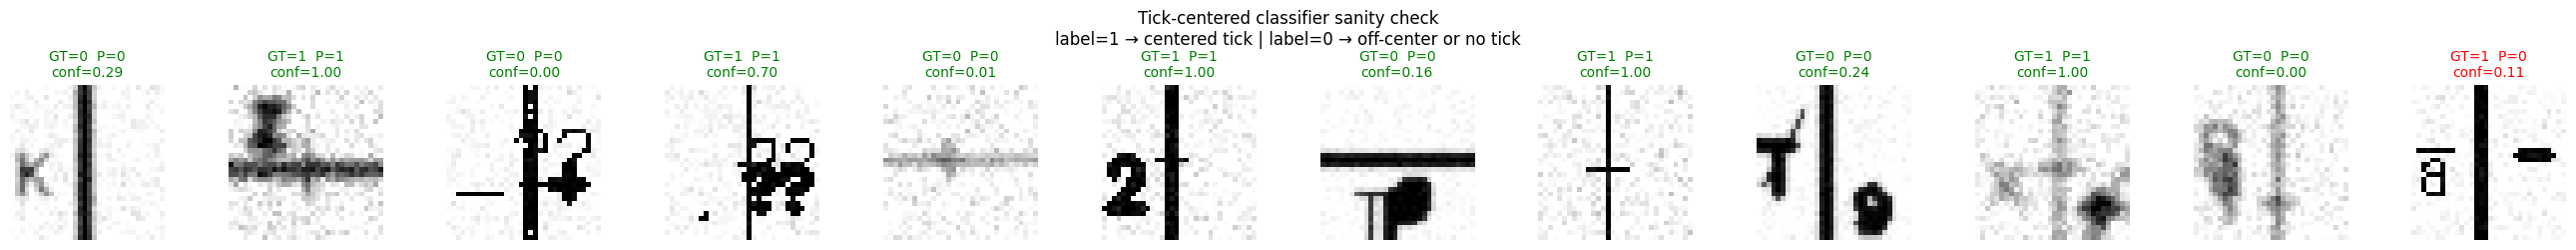

In [31]:
import torch
import numpy as np
import matplotlib.pyplot as plt

@torch.no_grad()
def show_tick_samples(
    model,
    n_samples: int = 12,
    threshold: float = 0.5,
    seed: int = None
):
    """
    Generate samples, run inference, and display them.

    Red title   → error
    Green title → correct

    label=1 : centered tick
    label=0 : includes off-center ticks and no-tick cases
    """

    device = "cuda" if torch.cuda.is_available() else "cpu"

    if seed is not None:
        np.random.seed(seed)

    model.eval()

    fig, axes = plt.subplots(1, n_samples, figsize=(2.2 * n_samples, 2.5))
    if n_samples == 1:
        axes = [axes]

    for i in range(n_samples):
        label = i % 2  # force mix of positives / negatives
        img = draw_sample(label)

        x = torch.tensor(img, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
        logits = model(x)
        prob = torch.softmax(logits, dim=1)[0, 1].item()
        pred = int(prob >= threshold)

        correct = (pred == label)

        color = "green" if correct else "red"

        axes[i].imshow(img, cmap="gray", vmin=0, vmax=1)
        axes[i].axis("off")

        axes[i].set_title(
            f"GT={label}  P={pred}\nconf={prob:.2f}",
            color=color,
            fontsize=10
        )

    plt.suptitle(
        "Tick-centered classifier sanity check\n"
        "label=1 → centered tick | label=0 → off-center or no tick",
        fontsize=12
    )
    plt.tight_layout()
    plt.show()
show_tick_samples(model)

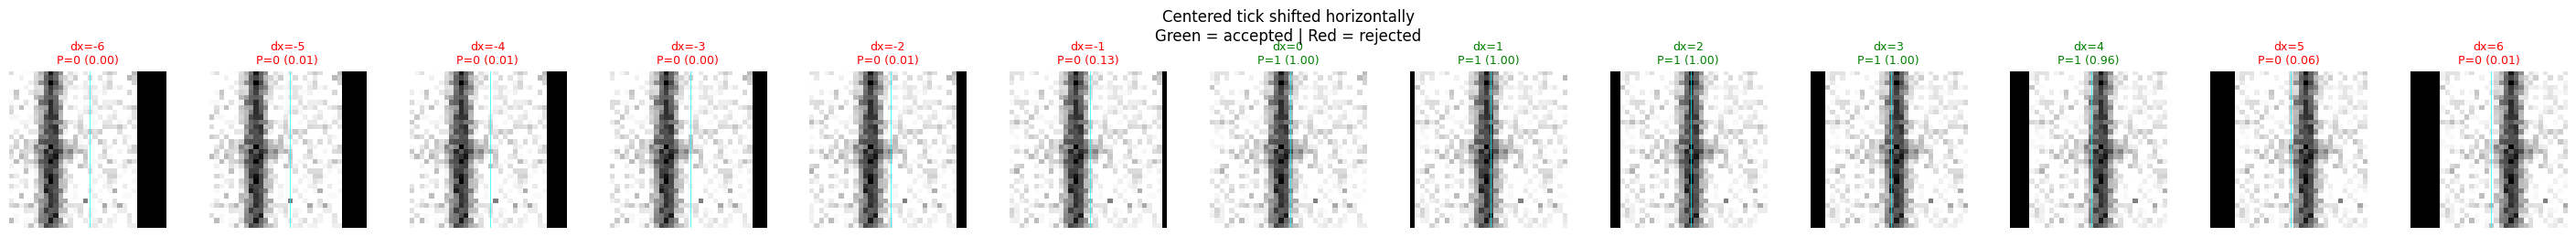

In [32]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2

@torch.no_grad()
def sweep_center_offsets(
    model,
    max_offset: int = 6,
    step: int = 1,
    threshold: float = 0.5,
    seed: int = None
):
    """
    Test model response as a centered tick is shifted away
    from the image center.

    Offsets are applied symmetrically in x-direction.
    """

    device = "cuda" if torch.cuda.is_available() else "cpu"
    if seed is not None:
        np.random.seed(seed)

    # --- generate ONE true centered positive ---
    base = draw_sample(label=1)

    offsets = list(range(-max_offset, max_offset + 1, step))
    n = len(offsets)

    fig, axes = plt.subplots(1, n, figsize=(2.2 * n, 2.6))
    if n == 1:
        axes = [axes]

    model.eval()

    H, W = base.shape
    cx, cy = W // 2, H // 2

    for ax, dx in zip(axes, offsets):
        # --- shift image ---
        M = np.float32([[1, 0, dx], [0, 1, 0]])
        shifted = cv2.warpAffine(
            base,
            M,
            (W, H),
            flags=cv2.INTER_LINEAR,
            borderValue=0
        )

        # --- inference ---
        x = torch.tensor(shifted, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)
        logits = model(x)
        prob = torch.softmax(logits, dim=1)[0, 1].item()
        pred = int(prob >= threshold)

        # --- visualize ---
        ax.imshow(shifted, cmap="gray", vmin=0, vmax=1)
        ax.axis("off")

        color = "green" if pred == 1 else "red"
        ax.set_title(
            f"dx={dx}\nP={pred} ({prob:.2f})",
            color=color,
            fontsize=9
        )

        # draw center reference
        ax.axvline(cx, color="cyan", linewidth=0.5)

    plt.suptitle(
        "Centered tick shifted horizontally\n"
        "Green = accepted | Red = rejected",
        fontsize=12
    )
    plt.tight_layout()
    plt.show()
sweep_center_offsets(model)

12


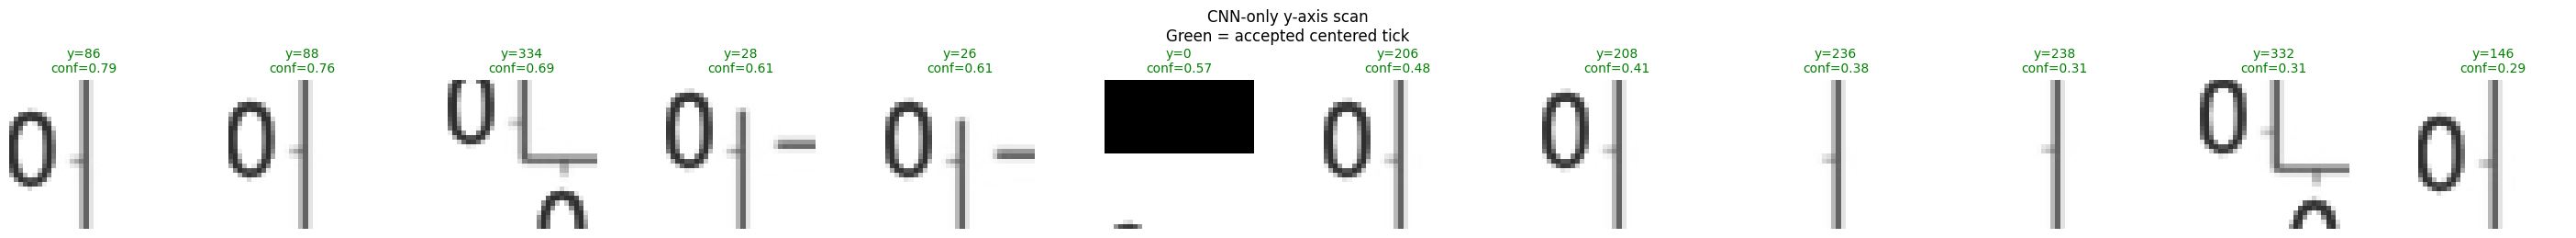

In [ ]:
import numpy as np
import torch
import cv2
from typing import List, Dict

@torch.no_grad()
def scan_y_axis_with_model_only(
    image: np.ndarray,
    y_axis_x: int,
    model,
    crop_size: int = 32,
    step: int = 2,
    threshold: float = 0.2,
    show_max: int = 12,
    show_only_positive: bool = False
) -> List[Dict]:
    """
    Scan along the y-axis using ONLY the CNN, and on a real image (not generated).

    Returns a list of dicts:
      - y_pixel
      - confidence
      - prediction
      - crop (32x32 float32)
    """
    device = "cuda" if torch.cuda.is_available() else "cpu"


    # --- grayscale + normalize ---
    if image.ndim == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image.copy()

    gray = gray.astype(np.float32) / 255.0

    H, W = gray.shape
    half = crop_size // 2

    crops = []
    ys = []

    # --- extract crops ---
    for y in range(0, H, step):
        cx = y_axis_x
        cy = y

        x0 = cx - half
        x1 = cx + half
        y0 = cy - half
        y1 = cy + half

        crop = np.zeros((crop_size, crop_size), dtype=np.float32)

        sx0 = max(0, x0)
        sx1 = min(W, x1)
        sy0 = max(0, y0)
        sy1 = min(H, y1)

        dx0 = sx0 - x0
        dy0 = sy0 - y0

        crop[
            dy0 : dy0 + (sy1 - sy0),
            dx0 : dx0 + (sx1 - sx0)
        ] = gray[sy0:sy1, sx0:sx1]

        crops.append(crop)
        ys.append(y)

    # --- batch inference ---
    x = torch.tensor(np.stack(crops), dtype=torch.float32).unsqueeze(1).to(device)

    model.eval()
    logits = model(x)
    probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()

    results = []
    for y, p, crop in zip(ys, probs, crops):
        results.append({
            "y_pixel": int(y),
            "confidence": float(p),
            "prediction": int(p >= threshold),
            "crop": crop
        })

    # --- select samples to show ---
    if show_only_positive:
        to_show = [r for r in results if r["prediction"] == 1]
    else:
      to_show = []
      for r in results:
        if np.random.rand() < 0.05:
          to_show.append(r)

    to_show = sorted(to_show, key=lambda r: -r["confidence"])[:show_max]

    if not to_show:
        print("No samples to display.")
        return results
    print(len(to_show))
    # --- visualization ---
    fig, axes = plt.subplots(
        1,
        len(to_show),
        figsize=(2.4 * len(to_show), 2.6)
    )

    if len(to_show) == 1:
        axes = [axes]

    for ax, r in zip(axes, to_show):
        ax.imshow(r["crop"], cmap="gray", vmin=0, vmax=1)
        ax.axis("off")
        ax.set_title(
            f"y={r['y_pixel']}\n"
            f"conf={r['confidence']:.2f}",
            color="green" if r["prediction"] else "red",
            fontsize=10
        )

    plt.suptitle(
        "CNN-only y-axis scan\n"
        "Green = accepted centered tick",
        fontsize=12
    )
    plt.tight_layout()
    plt.show()

    return results

image_path = "graphs/graph1.png"
img = cv2.imread(image_path, cv2.IMREAD_COLOR)
results = scan_y_axis_with_model_only(img, 73, model, show_only_positive = True)

In [91]:
results

[{'y_pixel': 0,
  'confidence': 0.0605955570936203,
  'prediction': 0,
  'crop': array([[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [1., 1., 1., ..., 1., 1., 1.],
         [1., 1., 1., ..., 1., 1., 1.],
         [1., 1., 1., ..., 1., 1., 1.]], dtype=float32)},
 {'y_pixel': 2,
  'confidence': 0.00025787579943425953,
  'prediction': 0,
  'crop': array([[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [1., 1., 1., ..., 1., 1., 1.],
         [1., 1., 1., ..., 1., 1., 1.],
         [1., 1., 1., ..., 1., 1., 1.]], dtype=float32)},
 {'y_pixel': 4,
  'confidence': 0.0010141980601474643,
  'prediction': 0,
  'crop': array([[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [1., 1., 1., ..., 1., 1., 1.],
         [1., 1., 1., ..., 1., 1., 1.]